In [65]:
import os, openpyxl, numpy as np
import matplotlib.pyplot as plt
import eis_loader, drt_solver, excel_processor
import importlib

# 수정 사항 즉시 반영
importlib.reload(drt_solver)
importlib.reload(excel_processor)

# --- 1. 기본 입력 및 엑셀 로드 ---
input_f = r"C:\Users\0528a\OneDrive\Desktop\EIS\EIS 측정\2026\260226\STF"
tmpl_p  = r"C:\Users\0528a\OneDrive\Desktop\EIS\EIS 분석\샘플.xlsm"
out_f   = r"C:\Users\0528a\OneDrive\Desktop\EIS\EIS 분석\2026"

user_name = input("1. 생성할 파일 이름: ")
radius, thick = input("2. 반지름: "), input("3. 두께: ")
drt_target_temp = input("4. DRT 분석 온도: ")

1. 생성할 파일 이름:  ㅇㄹ
2. 반지름:  0.8
3. 두께:  0.047
4. DRT 분석 온도:  700


⏳ NNLS 엔진으로 매트랩과 완벽히 동일한 다중 피크 생성 중...


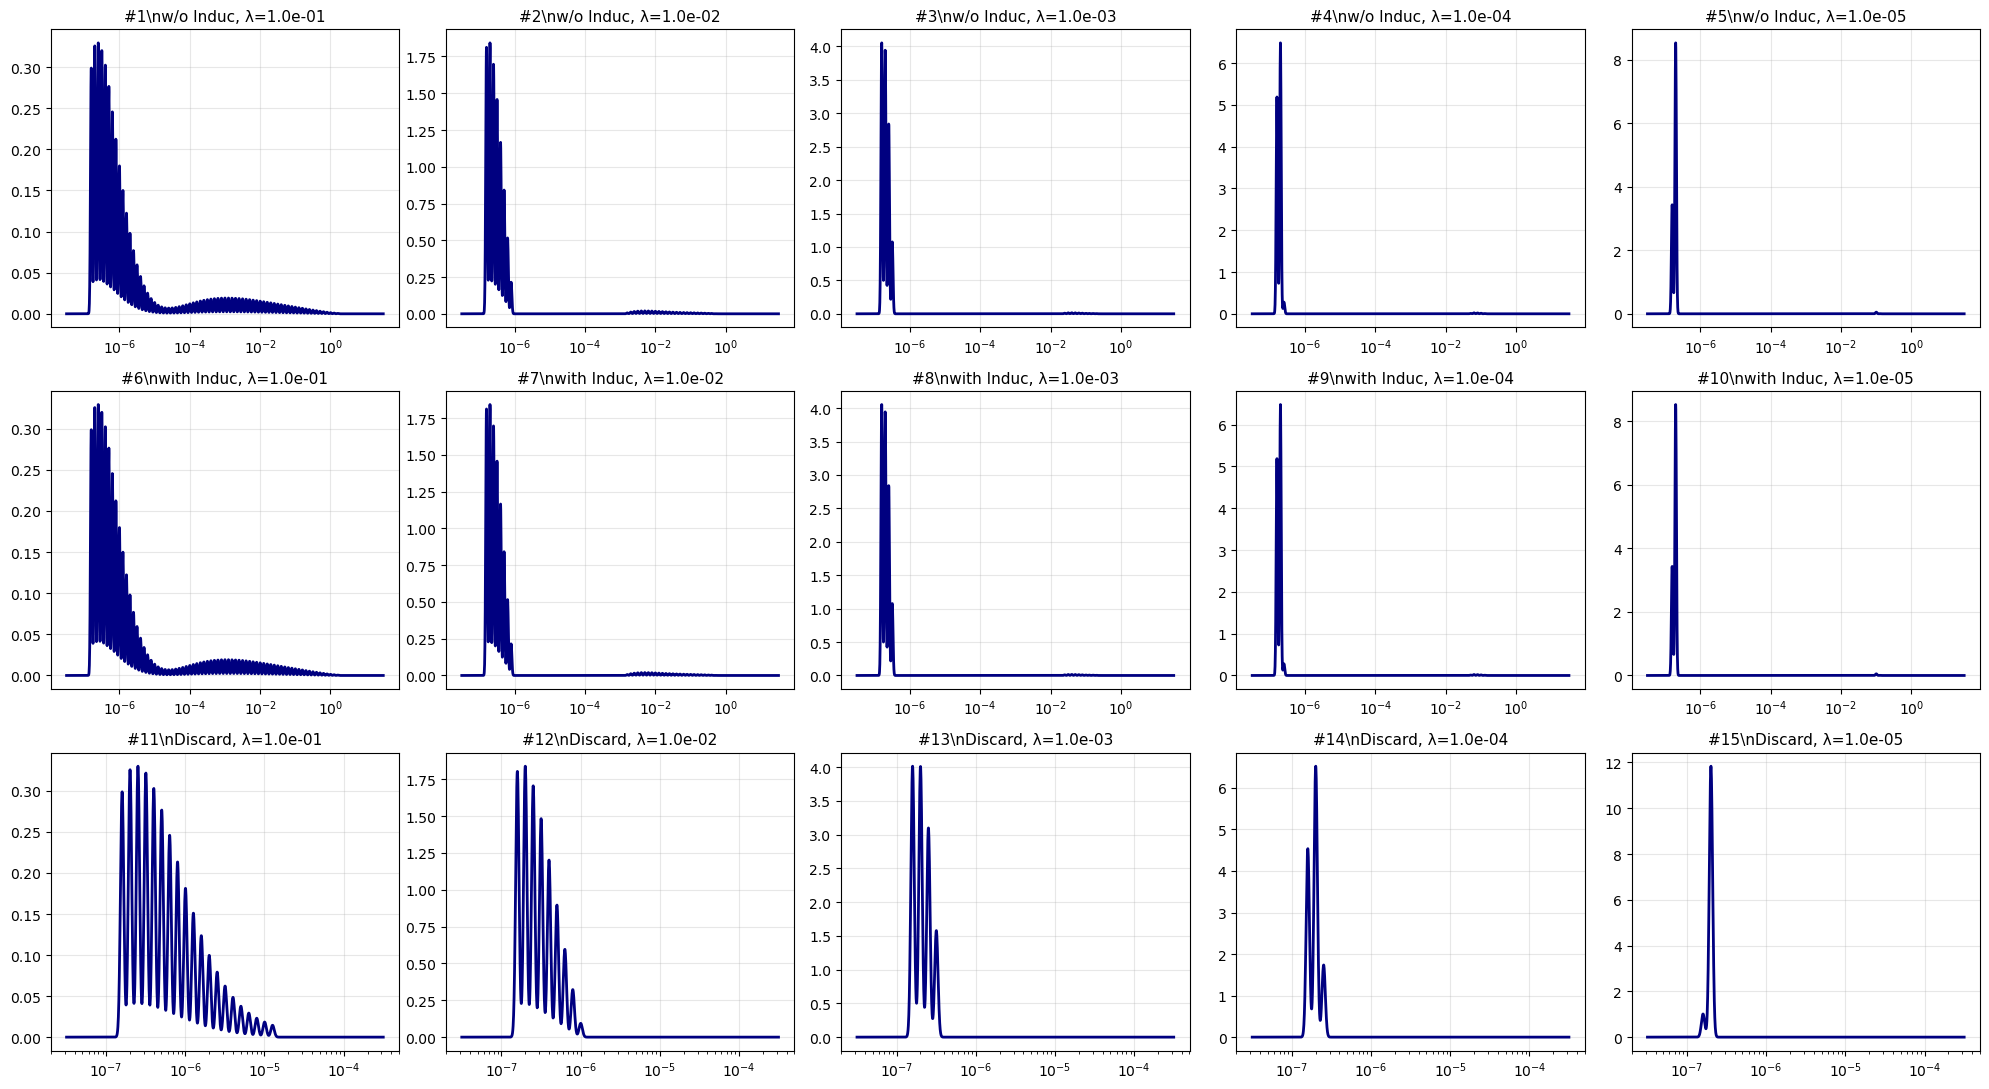

In [ ]:
file_map, temps = eis_loader.find_target_files(input_f)
sorted_temps = sorted(temps, key=int, reverse=True)
wb = openpyxl.load_workbook(tmpl_p, keep_vba=True)
drt_input = []

for t in sorted_temps:
    mpt_p = os.path.join(input_f, file_map[t])
    wb, current_drt = excel_processor.process_eis_to_excel(wb, t, mpt_p, 65, radius, thick, drt_target_temp)
    if current_drt: drt_input = current_drt

if not drt_input:
    print(f"❌ '{drt_target_temp}' 온도 데이터를 찾지 못했습니다.")
else:
    d_array = np.array(drt_input)
    
    # ⭐ [단 한 번만 계산] f, Re/2, -Im/2 적용
    freq = d_array[:, 0]
    re_half = d_array[:, 1] / 2
    neg_im_half = -d_array[:, 2] / 2 
    
    results = drt_solver.plot_15_graphs(freq, re_half, neg_im_half)
    
    choice = int(input("\n✔️ 마음에 드는 그래프 번호를 선택하세요 (1-15): "))
    sel_tau, sel_gamma = results[choice - 1]

    wb = excel_processor.finalize_drt_results(wb, drt_target_temp, sel_tau, sel_gamma)
    excel_processor.create_summary_sheet(wb, sorted_temps)
    
    if not os.path.exists(out_f): os.makedirs(out_f)
    wb.save(os.path.join(out_f, f"{user_name}.xlsm"))
    print(f"✅ 완료! {user_name}.xlsm이 정상 저장되었습니다.")